# Panglial Connexin Dynamics in EAE

This notebook revisits the MS single-cell connexin genes in the RRmap EAE atlas, using `stage` as the progression axis and `anno_L1` as the major cell-type axis.

The target genes are `GJC2` (Cx47), `GJB1` (Cx32), and `GJA1` (Cx43). If one of those genes is absent from the exported matrix, the notebook reports that explicitly and skips downstream plots for that gene.

Because `anno_L1` is intentionally coarse, the main analysis stays at level 1 and then adds an optional `anno_L2` glial zoom (`Astrocyte`, `OPC`, `Oligodendrocyte`) to reconnect more directly to the oligodendroglial and astrocytic framing used in `MS-sc.ipynb`.


In [14]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

CANDIDATES = [Path.cwd().resolve(), Path.cwd().resolve().parent]
REPO_ROOT = next((path for path in CANDIDATES if (path / "src").exists() and (path / "config").exists()), None)
if REPO_ROOT is None:
    raise RuntimeError("Could not locate the repository root. Start Jupyter from the repo root or notebooks directory.")

MPL_CACHE_DIR = REPO_ROOT / ".cache" / "matplotlib"
MPL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE_DIR))

if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from cx47_oligo.exports import ensure_results_dir, save_current_figure, save_json, save_table
from cx47_oligo.h5ad_tools import adata_overview, expression_frame, load_h5ad, obs_column_summary, resolve_gene_symbols

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#fbfcfd",
        "axes.edgecolor": "#d7dde2",
        "grid.color": "#dde4ea",
        "grid.alpha": 0.75,
    }
)


In [15]:
DEFAULT_DATASET_PATH = Path("/Volumes/processing2/RRmap/data/RRmap_metadata_fixed_update.h5ad")
DATA_ROOT = REPO_ROOT / "data" / "raw"
LOCAL_H5AD_FILES = sorted(DATA_ROOT.glob("*.h5ad"))

DATASET_PATH = DEFAULT_DATASET_PATH if DEFAULT_DATASET_PATH.exists() else (LOCAL_H5AD_FILES[0] if LOCAL_H5AD_FILES else None)
if DATASET_PATH is None or not DATASET_PATH.exists():
    raise FileNotFoundError("No EAE .h5ad file was found. Set DATASET_PATH manually to the RRmap atlas.")

RESULTS_DIR = ensure_results_dir(REPO_ROOT, "01_panglial_network_eae", DATASET_PATH)
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TARGET_GENES = ["GJC2", "GJB1", "GJA1"]
STAGE_COLUMN = "stage"
CELLTYPE_COLUMN = "anno_L1"
DETAIL_CELLTYPE_COLUMN = "anno_L2"
GLIAL_DETAIL_ORDER = ["Astrocyte", "OPC", "Oligodendrocyte"]

print("Dataset:", DATASET_PATH)
print("Results:", RESULTS_DIR)


Dataset: /Volumes/processing2/RRmap/data/RRmap_metadata_fixed_update.h5ad
Results: /Users/chrislangseth/work/karolinska_institutet/projects/cx47-oligo/results/01_panglial_network_eae/rrmap_metadata_fixed_update


In [16]:
adata = load_h5ad(DATASET_PATH)
display(adata_overview(adata))

required_columns = [STAGE_COLUMN, CELLTYPE_COLUMN]
missing_columns = [column for column in required_columns if column not in adata.obs.columns]
if missing_columns:
    raise KeyError(f"Missing required obs columns: {missing_columns}")

metadata_columns = [
    column
    for column in [
        STAGE_COLUMN,
        CELLTYPE_COLUMN,
        DETAIL_CELLTYPE_COLUMN,
        "condition",
        "course",
        "course_ordered",
        "day_of_sacrifice",
        "last_day",
        "sample_id",
    ]
    if column in adata.obs.columns
]
metadata_summary = obs_column_summary(adata).loc[lambda df: df["column"].isin(metadata_columns)]
display(metadata_summary)
save_table(metadata_summary, RESULTS_DIR / "core_obs_summary.csv", index=False)

present_genes, missing_genes, gene_to_var = resolve_gene_symbols(adata, TARGET_GENES)
gene_status = pd.DataFrame(
    {
        "query_gene": TARGET_GENES,
        "resolved_var": [gene_to_var.get(gene, "") for gene in TARGET_GENES],
        "present_in_dataset": [gene in present_genes for gene in TARGET_GENES],
    }
)
display(gene_status)
save_table(gene_status, RESULTS_DIR / "target_gene_status.csv", index=False)

save_json(
    {
        "dataset_path": str(DATASET_PATH),
        "results_dir": str(RESULTS_DIR),
        "stage_column": STAGE_COLUMN,
        "celltype_column": CELLTYPE_COLUMN,
        "detail_celltype_column": DETAIL_CELLTYPE_COLUMN if DETAIL_CELLTYPE_COLUMN in adata.obs.columns else None,
        "target_genes": TARGET_GENES,
        "present_genes": present_genes,
        "missing_genes": missing_genes,
    },
    RESULTS_DIR / "run_metadata.json",
)

if missing_genes:
    display(
        Markdown(
            "**Missing genes:** "
            + ", ".join(f"`{gene}`" for gene in missing_genes)
            + " are not present in this RRmap export, so the downstream plots only use the genes that are available."
        )
    )

if DETAIL_CELLTYPE_COLUMN in adata.obs.columns:
    available_detail_labels = sorted(map(str, adata.obs[DETAIL_CELLTYPE_COLUMN].dropna().unique()))
    glial_labels = [label for label in GLIAL_DETAIL_ORDER if label in available_detail_labels]
    if glial_labels:
        display(Markdown("**Glial detail available:** `anno_L2` contains " + ", ".join(f"`{label}`" for label in glial_labels) + "."))


,metric,value
0,n_obs,877141
1,n_vars,5101
2,obs_columns,97
3,var_columns,8
4,layers,"counts, normalized"
5,obsm,"X_mana_gauss, X_mana_gauss_2neigh, X_pca, X_sc..."
6,uns_keys,"Class_colors, Cluster_colors, Level1_colors, L..."
7,raw_present,False


,column,dtype,n_unique,null_fraction,examples
4,condition,category,2,0.000000,"EAE, CONTROL"
15,anno_L1,category,9,0.000000,"Schwann/PNS, Other/Artifact, Neuron, Myeloid"
25,stage,category,13,0.000000,"OS1, PEAK1, NONSYMPTOM, MOG CFA"
26,course,category,14,0.000000,"early onset, chronic peak, non symptomatic, MO..."
27,course_ordered,category,14,0.000000,"early onset, chronic peak, non symptomatic, MO..."
38,anno_L2,category,21,0.000000,"Schwann cell, Artifact, Interneuron, Macrophage"
39,day_of_sacrifice,int64,22,0.000000,"12, 16, 9, 14"
40,last_day,float64,22,0.005671,"12.0, 16.0, 9.0, 14.0"
88,sample_id,category,107,0.000000,"G3_L1_0, G3_L1_1, G3_L1_2, G3_L2_0"


,query_gene,resolved_var,present_in_dataset
0,GJC2,,False
1,GJB1,Gjb1,True
2,GJA1,Gja1,True


**Missing genes:** `GJC2` are not present in this RRmap export, so the downstream plots only use the genes that are available.

**Glial detail available:** `anno_L2` contains `Astrocyte`, `OPC`, `Oligodendrocyte`.

In [22]:
def unique_text(series):
    values = [str(value) for value in pd.Series(series).dropna().astype(str).unique()]
    return ", ".join(values)


def reorder_matrix(frame, row_order=None, col_order=None):
    working = frame.copy()
    if row_order is not None:
        rows = [row for row in row_order if row in working.index]
        extra_rows = [row for row in working.index if row not in rows]
        working = working.reindex(rows + extra_rows)
    if col_order is not None:
        cols = [col for col in col_order if col in working.columns]
        extra_cols = [col for col in working.columns if col not in cols]
        working = working.reindex(columns=cols + extra_cols)
    return working


def plot_heatmap(frame, title, cmap="mako"):
    fig, ax = plt.subplots(figsize=(max(8, 0.75 * len(frame.columns) + 3), max(4.5, 0.55 * len(frame.index) + 2)))
    sns.heatmap(frame, cmap=cmap, linewidths=0.4, linecolor="white", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.xticks(rotation=90, ha="center")
    plt.yticks(rotation=0)
    plt.tight_layout()


def stage_summary_table(adata_input, stage_col=STAGE_COLUMN):
    base_columns = [stage_col] + [column for column in ["condition", "course", "course_ordered", "day_of_sacrifice", "last_day"] if column in adata_input.obs.columns]
    frame = adata_input.obs[base_columns].copy().dropna(subset=[stage_col])
    group = frame.groupby(stage_col, observed=True)

    summary = group.size().rename("n_cells").to_frame()
    for column in ["condition", "course", "course_ordered"]:
        if column in frame.columns:
            summary[column] = group[column].agg(unique_text)
    for column in ["day_of_sacrifice", "last_day"]:
        if column in frame.columns:
            summary[f"{column}_min"] = group[column].min()
            summary[f"{column}_median"] = group[column].median()
            summary[f"{column}_max"] = group[column].max()

    summary = summary.reset_index()
    sort_columns = [column for column in ["last_day_median", "day_of_sacrifice_median", "condition", stage_col] if column in summary.columns]
    if sort_columns:
        summary = summary.sort_values(sort_columns, kind="stable")
    else:
        summary = summary.sort_values(stage_col, kind="stable")
    return summary.set_index(stage_col)


def stage_celltype_count_matrix(adata_input, stage_col, celltype_col):
    frame = adata_input.obs[[stage_col, celltype_col]].copy().dropna(subset=[stage_col, celltype_col])
    frame[stage_col] = frame[stage_col].astype(str)
    frame[celltype_col] = frame[celltype_col].astype(str)
    return frame.groupby([stage_col, celltype_col], observed=True).size().unstack(celltype_col).fillna(0).astype(int)


def stage_celltype_expression_stats(adata_input, genes, stage_col, celltype_col):
    expr = expression_frame(adata_input, genes)
    if expr.empty:
        empty = pd.DataFrame()
        return {"n_cells": empty, "mean_expression": empty, "pct_expressing": empty}

    frame = adata_input.obs[[stage_col, celltype_col]].copy().join(expr).dropna(subset=[stage_col, celltype_col])
    frame[stage_col] = frame[stage_col].astype(str)
    frame[celltype_col] = frame[celltype_col].astype(str)
    gene_columns = list(expr.columns)
    group_cols = [stage_col, celltype_col]

    counts = frame.groupby(group_cols, observed=True).size().rename("n_cells").to_frame()
    mean_expression = frame.groupby(group_cols, observed=True)[gene_columns].mean()

    detected = frame[gene_columns].gt(0).astype(float)
    detected[stage_col] = frame[stage_col].values
    detected[celltype_col] = frame[celltype_col].values
    pct_expressing = detected.groupby(group_cols, observed=True)[gene_columns].mean().mul(100.0)

    return {
        "n_cells": counts,
        "mean_expression": mean_expression,
        "pct_expressing": pct_expressing,
    }


def plot_gene_stage_celltype_heatmaps(
    mean_expression,
    pct_expressing,
    gene,
    stage_col,
    celltype_col,
    row_order,
    col_order,
    title_prefix,
    mean_cmap="crest",
    pct_cmap="rocket",
):
    mean_matrix = reorder_matrix(mean_expression[[gene]].unstack(celltype_col)[gene], row_order, col_order)
    pct_matrix = reorder_matrix(pct_expressing[[gene]].unstack(celltype_col)[gene], row_order, col_order)

    fig, axes = plt.subplots(1, 2, figsize=(max(12, 0.9 * len(mean_matrix.columns) + 8), max(4.5, 0.6 * len(mean_matrix.index) + 2.5)))
    sns.heatmap(mean_matrix, cmap=mean_cmap, linewidths=0.4, linecolor="white", ax=axes[0])
    axes[0].set_title(f"{title_prefix}: {gene} mean expression")
    axes[0].set_xlabel("")
    axes[0].set_ylabel(stage_col)

    sns.heatmap(pct_matrix, cmap=pct_cmap, linewidths=0.4, linecolor="white", ax=axes[1])
    axes[1].set_title(f"{title_prefix}: {gene} % expressing")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("")

    for ax in axes:
        ax.tick_params(axis="x", rotation=90)
        ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()


def plot_stage_line_panels(mean_expression, genes, stage_col, celltype_col, row_order, col_order, title):
    long_df = (
        mean_expression.reset_index()
        .melt(id_vars=[stage_col, celltype_col], value_vars=genes, var_name="gene", value_name="mean_expression")
    )
    observed_stages = list(pd.unique(long_df[stage_col]))
    observed_celltypes = list(pd.unique(long_df[celltype_col]))
    long_df[stage_col] = pd.Categorical(long_df[stage_col], categories=[label for label in row_order if label in observed_stages], ordered=True)
    long_df[celltype_col] = pd.Categorical(long_df[celltype_col], categories=[label for label in col_order if label in observed_celltypes], ordered=True)

    fig, axes = plt.subplots(1, len(genes), figsize=(max(8, 10* len(genes)), 5), sharey=False)
    if len(genes) == 1:
        axes = [axes]

    for ax, gene in zip(axes, genes):
        gene_df = long_df.loc[long_df["gene"] == gene].sort_values(stage_col)
        sns.lineplot(
            data=gene_df,
            x=stage_col,
            y="mean_expression",
            hue=celltype_col,
            style=celltype_col,
            markers=True,
            dashes=False,
            sort=False,
            ax=ax,
        )
        ax.set_title(gene)
        ax.set_xlabel(stage_col)
        ax.set_ylabel("Mean expression")
        ax.tick_params(axis="x", rotation=90)
        ax.legend(title=celltype_col.replace("_", " "), bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

    fig.suptitle(title, y=1.04)
    plt.tight_layout()


## Stage Composition

These cells establish the stage order using the available sacrifice-day metadata, then show how the major `anno_L1` compartments are distributed across the EAE time axis.


,n_cells,condition,course,course_ordered,day_of_sacrifice_min,day_of_sacrifice_median,day_of_sacrifice_max,last_day_min,last_day_median,last_day_max
stage,,,,,,,,,,
MOG CFA,35776,CONTROL,MOG CFA,MOG CFA,8,9.0,9,8.0,9.0,9.0
NONSYMPTOM,30878,EAE,non symptomatic,non symptomatic,9,9.0,9,9.0,9.0,9.0
OS1,56541,EAE,"early onset, chronic long","early onset, chronic long",12,12.0,14,12.0,12.0,14.0
ONSET2,39470,EAE,onset II,onset II,13,13.0,13,13.0,13.0,13.0
ONSET1,37087,EAE,onset I,onset I,11,11.0,15,11.0,15.0,15.0
PEAK1,157620,EAE,"chronic peak, peak I","chronic peak, peak I",16,18.0,18,16.0,18.0,18.0
REMISSION1,71522,EAE,remitt I,remitt I,20,21.0,25,20.0,21.0,25.0
PEAK2,83996,EAE,"peak I, peak II","peak I, peak II",31,31.0,33,31.0,31.0,33.0
PLP CFA,59168,CONTROL,PLP CFA,PLP CFA,33,33.0,33,33.0,33.0,33.0


anno_L1,Border/Fibroblast,Glia,Lymphoid,Myeloid,Neuron,Other,Other/Artifact,Schwann/PNS,Vascular
stage,,,,,,,,,
MOG CFA,2487,15077,41,1092,9677,371,210,2131,4690
NONSYMPTOM,1731,13762,33,1036,9216,314,271,510,4005
OS1,3329,19672,1288,7436,13427,453,904,3556,6476
ONSET2,2397,15289,1079,5723,8655,299,502,1411,4115
ONSET1,2875,15293,653,3406,9541,286,453,918,3662
PEAK1,8618,42164,13215,54825,21149,810,1860,3073,11906
REMISSION1,4810,24094,5144,16204,12526,458,923,1857,5506
PEAK2,6189,27445,4393,22807,14024,423,1108,1194,6413
PLP CFA,6254,24470,82,1728,17364,530,381,2194,6165


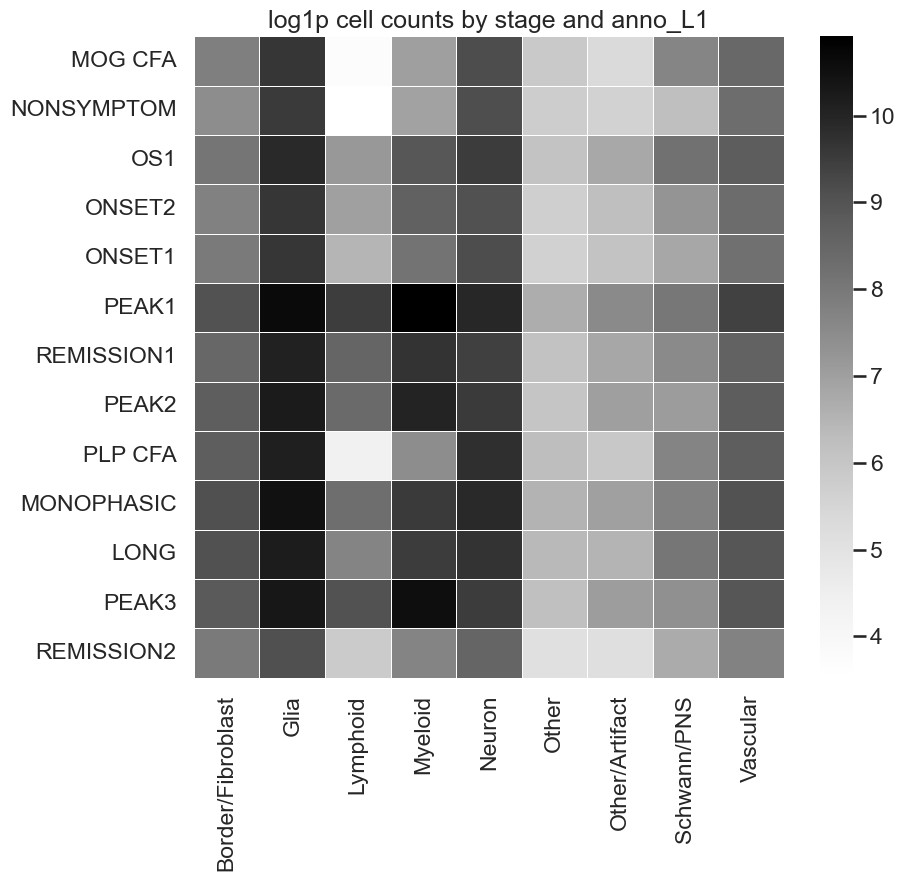

In [18]:
stage_summary = stage_summary_table(adata)
display(stage_summary)
save_table(stage_summary, RESULTS_DIR / "stage_summary.csv")

STAGE_ORDER = stage_summary.index.tolist()
if isinstance(adata.obs[CELLTYPE_COLUMN].dtype, pd.CategoricalDtype):
    CELLTYPE_ORDER = [str(category) for category in adata.obs[CELLTYPE_COLUMN].cat.categories]
else:
    CELLTYPE_ORDER = adata.obs[CELLTYPE_COLUMN].astype(str).value_counts().index.tolist()

l1_count_matrix = reorder_matrix(
    stage_celltype_count_matrix(adata, STAGE_COLUMN, CELLTYPE_COLUMN),
    STAGE_ORDER,
    CELLTYPE_ORDER,
)
display(l1_count_matrix)
save_table(l1_count_matrix, RESULTS_DIR / "anno_L1_cell_counts_by_stage.csv")

plot_heatmap(np.log1p(l1_count_matrix), "log1p cell counts by stage and anno_L1", cmap="Greys")
#save_current_figure(FIGURES_DIR / "anno_L1_cell_counts_by_stage.png")


## Stage-by-anno_L1 Connexin Dynamics

This section asks where the MS notebook genes appear across the EAE atlas at the major-compartment level. Each gene gets a paired mean-expression and percent-expressing heatmap over `stage × anno_L1`.


n_cells  GJB1_mean  GJA1_mean  GJB1_pct  \
stage      anno_L1                                                      
LONG       Border/Fibroblast     8794      0.065      1.296     2.900   
           Glia                 27230      0.892      1.974    40.474   
           Lymphoid              2190      0.121      0.620     5.708   
           Myeloid              13541      0.155      0.743     8.404   
           Neuron               16061      0.159      1.638    11.002   
...                               ...        ...        ...       ...   
REMISSION2 Neuron                5077      0.119      1.331     7.741   
           Other                  163      0.075      2.700     3.681   
           Other/Artifact         174      0.024      0.448     0.575   
           Schwann/PNS            818      0.683      0.120    23.472   
           Vascular              2330      0.121      1.621     6.009   

                              GJA1_pct  
stage      anno_L1                      
LONG       Border/Fibroblast    43.291  
           Glia                 57.686  
           Lymphoid             25.251  
           Myeloid              29.134  
           Neuron               59.050  
...                                ...  
REMISSION2 Neuron               51.034  
           Other                73.620  
           Other/Artifact       10.345  
           Schwann/PNS           4.034  
           Vascular             55.622  

[117 rows x 5 columns]

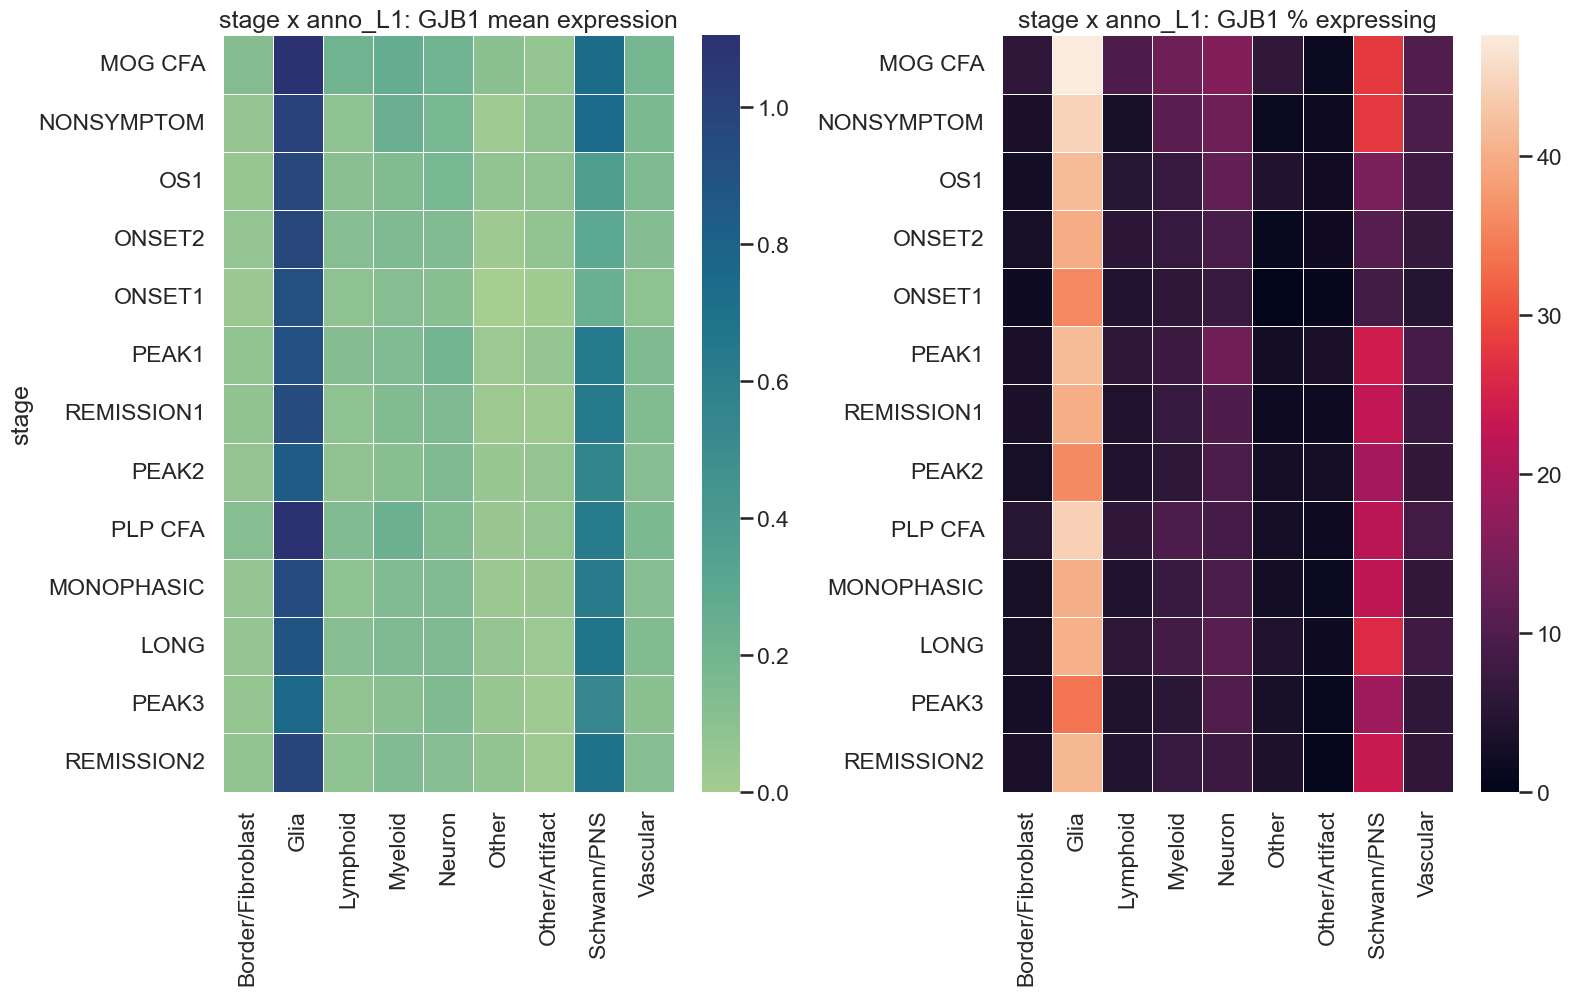

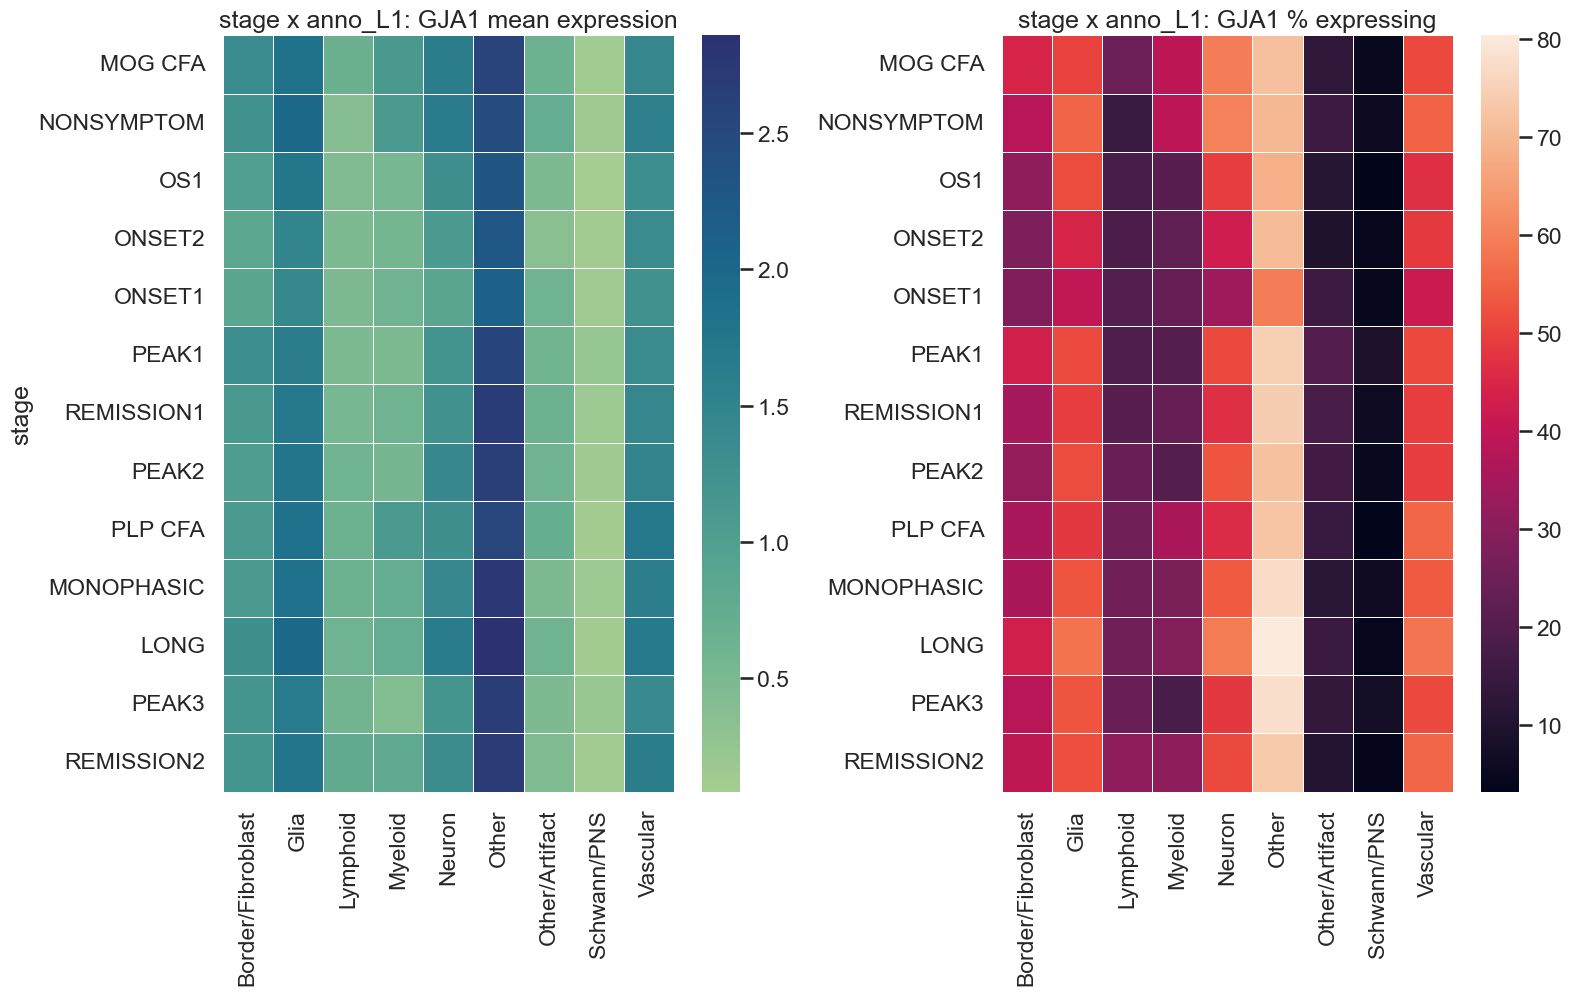

In [ ]:
if not present_genes:
    print("None of the target genes are present in this dataset export.")
else:
    l1_stats = stage_celltype_expression_stats(adata, TARGET_GENES, STAGE_COLUMN, CELLTYPE_COLUMN)
    l1_mean = l1_stats["mean_expression"]
    l1_pct = l1_stats["pct_expressing"]
    l1_summary = l1_stats["n_cells"].join(l1_mean.add_suffix("_mean")).join(l1_pct.add_suffix("_pct"))

    display(l1_summary.round(3))
    save_table(l1_summary, RESULTS_DIR / "anno_L1_connexin_stats_by_stage.csv")

    for gene in present_genes:
        plot_gene_stage_celltype_heatmaps(
            l1_mean,
            l1_pct,
            gene=gene,
            stage_col=STAGE_COLUMN,
            celltype_col=CELLTYPE_COLUMN,
            row_order=STAGE_ORDER,
            col_order=CELLTYPE_ORDER,
            title_prefix="stage x anno_L1",
        )
        #save_current_figure(FIGURES_DIR / f"{gene.lower()}_anno_L1_by_stage.png")


## Glial Detail Follow-Up

The broad `Glia` label in `anno_L1` hides the astrocyte versus oligodendrocyte split that matters most for `GJA1`, `GJB1`, and `GJC2`. If `anno_L2` is available, the next cell zooms into `Astrocyte`, `OPC`, and `Oligodendrocyte` so the EAE trajectories are easier to compare back to the MS notebook.


anno_L2,Astrocyte,OPC,Oligodendrocyte
stage,,,
MOG CFA,3989,719,10369
NONSYMPTOM,4034,711,9017
OS1,7036,1133,11503
ONSET2,4651,955,9683
ONSET1,4537,911,9845
PEAK1,15790,4207,22167
REMISSION1,7881,1952,14261
PEAK2,9818,2286,15341
PLP CFA,6832,1332,16306


n_cells  GJB1_mean  GJA1_mean  GJB1_pct  GJA1_pct
stage      anno_L2                                                           
LONG       Astrocyte          10422      0.355      3.467    19.104    88.457
           OPC                 1551      0.312      1.165    15.925    44.294
           Oligodendrocyte    15257      1.318      1.037    57.567    38.028
MOG CFA    Astrocyte           3989      0.376      4.405    19.278    98.195
           OPC                  719      0.323      1.029    15.994    38.665
           Oligodendrocyte    10369      1.440      0.881    60.681    32.404
MONOPHASIC Astrocyte          12030      0.295      3.563    15.719    88.712
           OPC                 2365      0.287      1.114    13.488    40.169
           Oligodendrocyte    20417      1.418      0.910    57.731    33.330
NONSYMPTOM Astrocyte           4034      0.344      4.309    18.171    97.447
           OPC                  711      0.326      1.219    16.315    43.038
           Oligodendrocyte     9017      1.358      0.997    58.534    37.318
ONSET1     Astrocyte           4537      0.233      3.573    12.321    90.346
           OPC                  911      0.232      0.695    10.428    24.698
           Oligodendrocyte     9845      1.299      0.499    49.121    17.776
ONSET2     Astrocyte           4651      0.286      3.463    15.158    90.755
           OPC                  955      0.355      0.815    16.335    31.204
           Oligodendrocyte     9683      1.364      0.623    53.940    23.309
OS1        Astrocyte           7036      0.324      3.433    17.638    89.994
           OPC                 1133      0.294      0.947    14.475    36.540
           Oligodendrocyte    11503      1.438      0.782    58.854    29.444
PEAK1      Astrocyte          15790      0.388      3.083    23.287    85.478
           OPC                 4207      0.312      0.943    16.805    37.580
           Oligodendrocyte    22167      1.398      0.705    59.232    29.566
PEAK2      Astrocyte           9818      0.371      3.351    19.434    86.056
           OPC                 2286      0.251      1.053    12.555    37.927
           Oligodendrocyte    15341      1.225      0.850    50.531    31.413
PEAK3      Astrocyte          11992      0.283      2.936    15.794    82.872
           OPC                 3193      0.236      1.097    12.402    41.748
           Oligodendrocyte    15240      1.237      0.772    52.257    31.391
PLP CFA    Astrocyte           6832      0.266      4.398    13.466    97.658
           OPC                 1332      0.375      1.081    17.192    37.838
           Oligodendrocyte    16306      1.515      0.820    59.187    28.394
REMISSION1 Astrocyte           7881      0.313      3.567    17.066    88.923
           OPC                 1952      0.315      1.088    15.676    39.652
           Oligodendrocyte    14261      1.383      0.760    56.265    28.336
REMISSION2 Astrocyte           3113      0.329      3.445    16.801    88.050
           OPC                  507      0.294      0.994    14.201    37.870
           Oligodendrocyte     5429      1.429      0.861    57.561    32.216

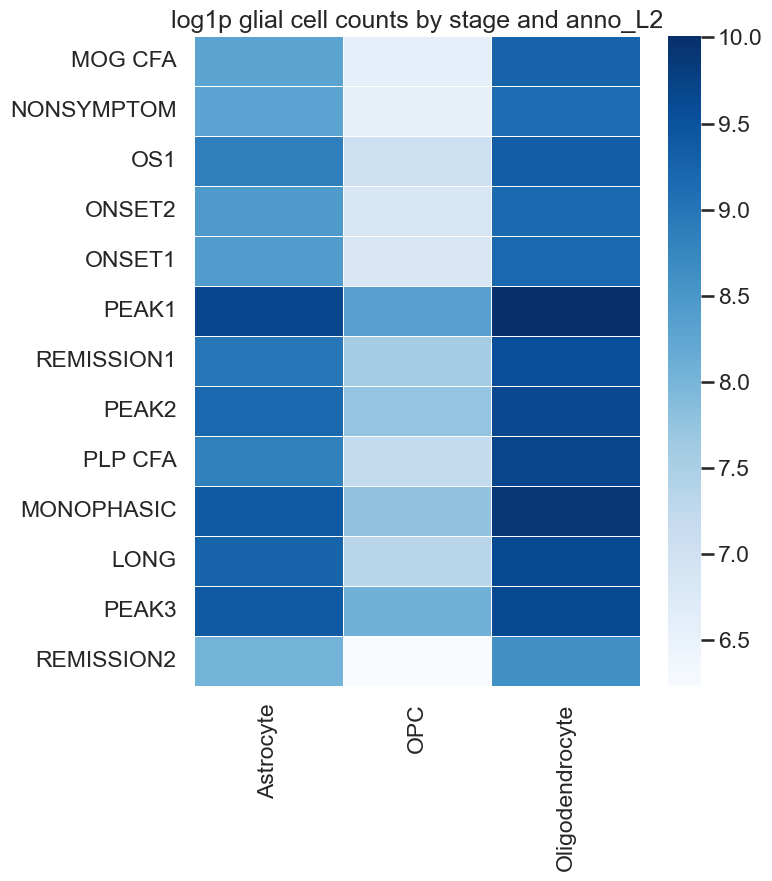

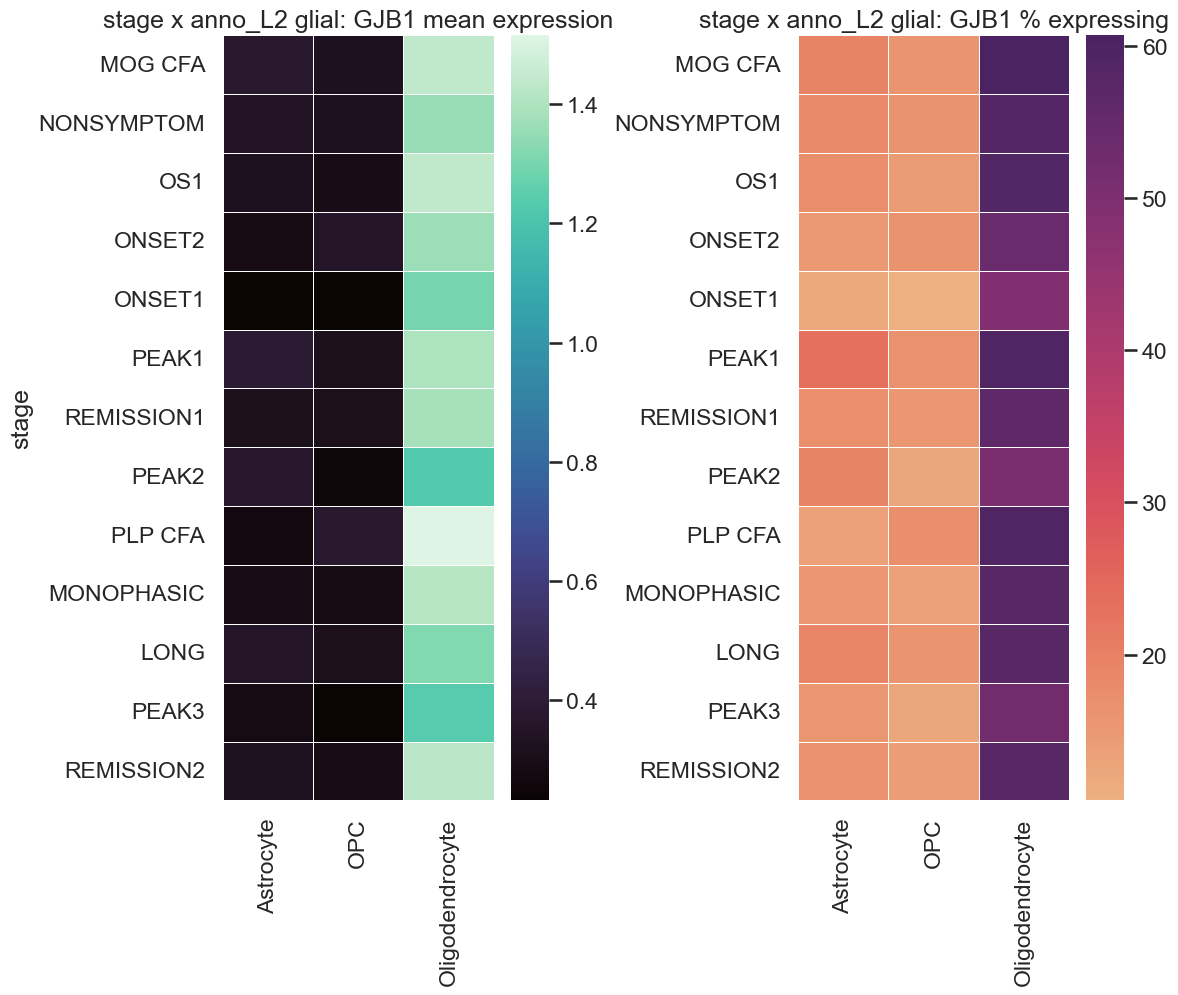

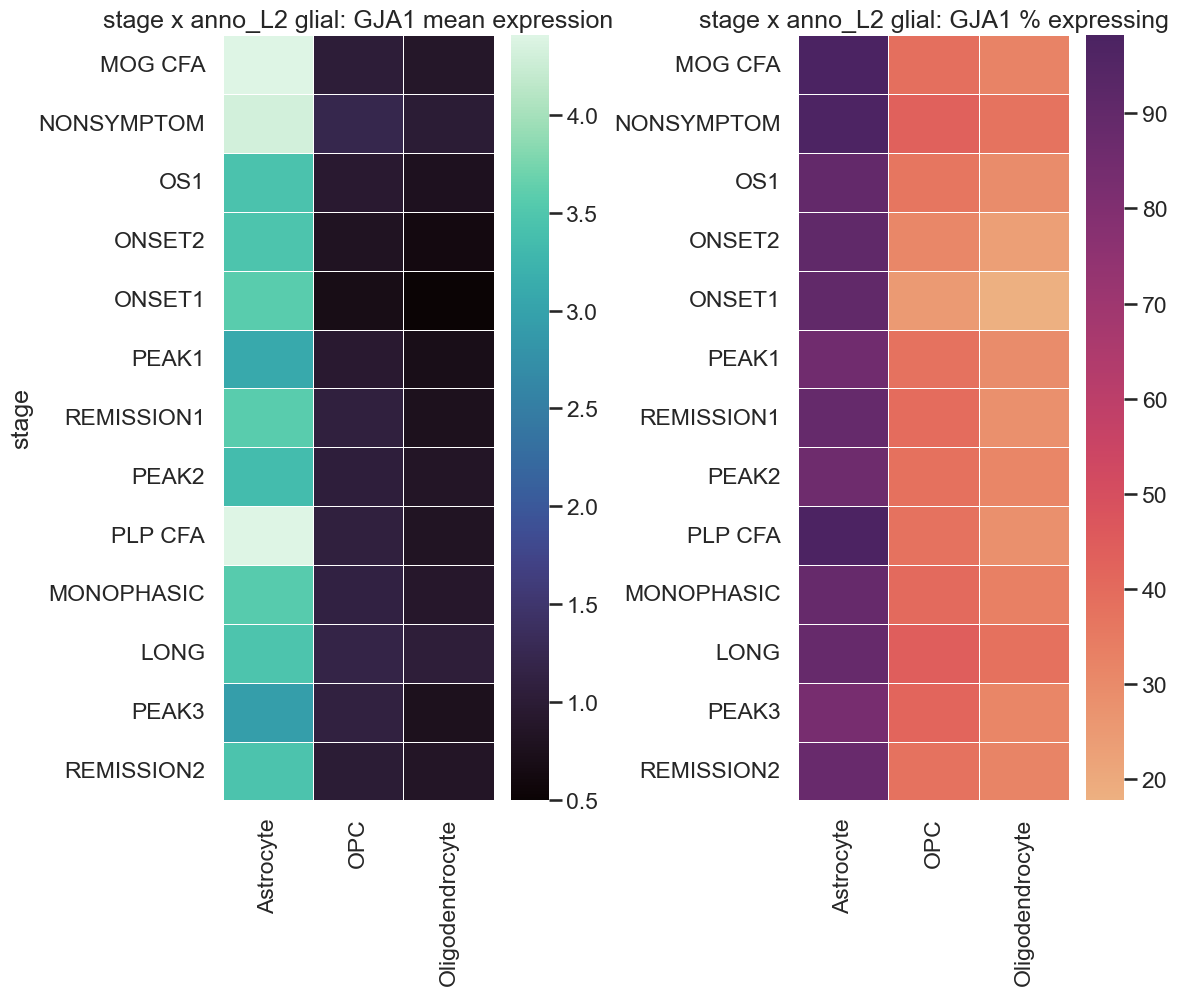

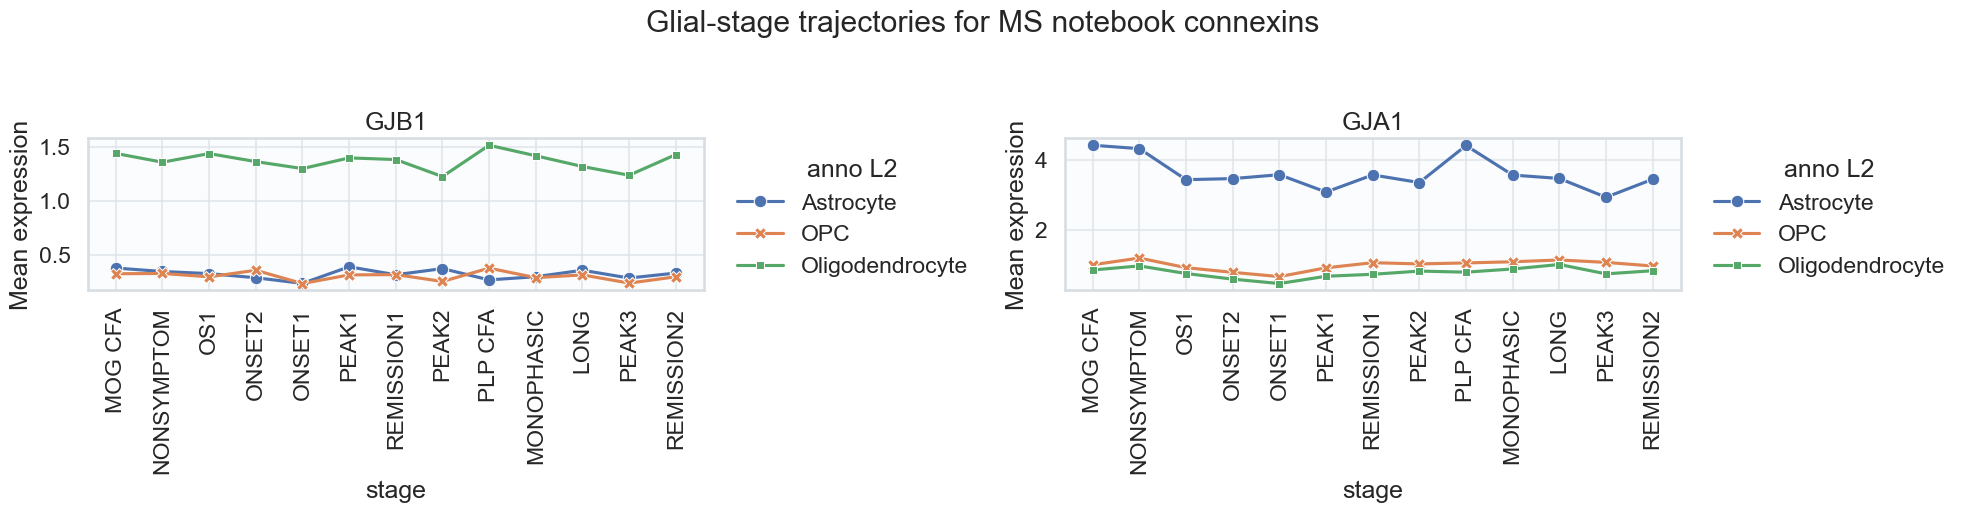

In [23]:
if DETAIL_CELLTYPE_COLUMN not in adata.obs.columns:
    print("No anno_L2 column is available in this atlas export.")
else:
    available_detail_labels = sorted(map(str, adata.obs[DETAIL_CELLTYPE_COLUMN].dropna().unique()))
    glial_labels = [label for label in GLIAL_DETAIL_ORDER if label in available_detail_labels]

    if not glial_labels:
        print("anno_L2 is present, but it does not contain the expected glial labels.")
    elif not present_genes:
        print("None of the target genes are present, so there is nothing to plot at anno_L2 resolution.")
    else:
        glial_mask = adata.obs[DETAIL_CELLTYPE_COLUMN].astype(str).isin(glial_labels)
        adata_glial_detail = adata[glial_mask]

        glial_counts = reorder_matrix(
            stage_celltype_count_matrix(adata_glial_detail, STAGE_COLUMN, DETAIL_CELLTYPE_COLUMN),
            STAGE_ORDER,
            glial_labels,
        )
        display(glial_counts)
        save_table(glial_counts, RESULTS_DIR / "anno_L2_glial_cell_counts_by_stage.csv")

        plot_heatmap(np.log1p(glial_counts), "log1p glial cell counts by stage and anno_L2", cmap="Blues")
        #save_current_figure(FIGURES_DIR / "anno_L2_glial_cell_counts_by_stage.png")

        glial_stats = stage_celltype_expression_stats(adata_glial_detail, TARGET_GENES, STAGE_COLUMN, DETAIL_CELLTYPE_COLUMN)
        glial_mean = glial_stats["mean_expression"]
        glial_pct = glial_stats["pct_expressing"]
        glial_summary = glial_stats["n_cells"].join(glial_mean.add_suffix("_mean")).join(glial_pct.add_suffix("_pct"))

        display(glial_summary.round(3))
        save_table(glial_summary, RESULTS_DIR / "anno_L2_glial_connexin_stats_by_stage.csv")

        for gene in present_genes:
            plot_gene_stage_celltype_heatmaps(
                glial_mean,
                glial_pct,
                gene=gene,
                stage_col=STAGE_COLUMN,
                celltype_col=DETAIL_CELLTYPE_COLUMN,
                row_order=STAGE_ORDER,
                col_order=glial_labels,
                title_prefix="stage x anno_L2 glial",
                mean_cmap="mako",
                pct_cmap="flare",
            )
            #save_current_figure(FIGURES_DIR / f"{gene.lower()}_anno_L2_glial_by_stage.png")

        plot_stage_line_panels(
            glial_mean,
            genes=present_genes,
            stage_col=STAGE_COLUMN,
            celltype_col=DETAIL_CELLTYPE_COLUMN,
            row_order=STAGE_ORDER,
            col_order=glial_labels,
            title="Glial-stage trajectories for MS notebook connexins",
        )
        #save_current_figure(FIGURES_DIR / "anno_L2_glial_connexin_stage_trajectories.png")
